In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# import os
# import torch
# os.environ['TORCH'] = torch.__version__
# print(torch.__version__)

In [4]:
# !pip install -q torch_geometric
# !pip install -q class_resolver
# !pip3 install pymatting


In [5]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
from scipy import sparse
from scipy.sparse.linalg import eigsh

In [6]:
fa_feature_path = "/home/snu/Downloads/Histogram_CN_FA_20bin_updated.npy"
Histogram_feature_CN_FA_array = np.load(fa_feature_path, allow_pickle=True)

# Load MCI features
fa_feature_path = "/home/snu/Downloads/Histogram_MCI_FA_20bin_updated.npy"
Histogram_feature_MCI_FA_array = np.load(fa_feature_path, allow_pickle=True)

# Combine features and labels
X = np.vstack([Histogram_feature_CN_FA_array, Histogram_feature_MCI_FA_array])
y = np.hstack([
    np.zeros(Histogram_feature_CN_FA_array.shape[0], dtype=np.int64),
    np.ones(Histogram_feature_MCI_FA_array.shape[0], dtype=np.int64)
])
np.random.seed(42)
perm = np.random.permutation(X.shape[0])
X = X[perm]
y = y[perm]
num_nodes, num_feats = X.shape
print(f"Features: {X.shape}, Labels: {y.shape}")

Features: (300, 180), Labels: (300,)


In [7]:
# F = np.concatenate((Histogram_feature_CN_FA_array, Histogram_feature_MCI_FA_array), axis=0)
# F = F.astype(np.float32)
# print("Combined Shape:", F.shape)
F = X
F = F.astype(np.float32)
print("Final Shape:", F.shape)
print("Data Type:", F.dtype)

Final Shape: (300, 180)
Data Type: float32


In [8]:
def tokencut_on_features(F_array, alpha=1e-6):
    """
    Apply TokenCut clustering to feature matrix F_array (shape: N × D).
    Returns binary labels (0/1) for each node.
    """
    N, D = F_array.shape

    # 1. Normalize features row-wise
    norms = np.linalg.norm(F_array, axis=1, keepdims=True) + 1e-10
    F_norm = F_array / norms

    # 2. Construct cosine similarity matrix (fully connected)
    W = np.dot(F_norm, F_norm.T)
    W = W + alpha  # stabilizer

    # 3. Normalized Laplacian: L = I - D^{-1/2} W D^{-1/2}  where, W is the similarity matrix and D is the degree matrix
    d = np.sum(W, axis=1)
    d_inv_sqrt = np.diag(1.0 / np.sqrt(d + 1e-10))
    L = np.eye(N) - d_inv_sqrt @ W @ d_inv_sqrt

    # Sparse for efficiency
    L_sparse = sparse.csr_matrix(L)

    # 4. Compute the Fiedler vector, i.e., the second smallest eigenvector of L.
    vals, vecs = eigsh(L_sparse, k=2, which='SM')
    fiedler = vecs[:, 1]

    # 5. Threshold by mean
    threshold = fiedler.mean()
    labels = (fiedler > threshold).astype(np.int64)

    return labels, fiedler

In [9]:
labels, scores = tokencut_on_features(X)

# Evaluate
y_pred = labels
acc = accuracy_score(y, y_pred)
inv_acc = accuracy_score(y, 1 - y_pred)
if inv_acc > acc:
    y_pred = 1 - y_pred
    acc = inv_acc

prec = precision_score(y, y_pred)
rec = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

# Normalize fiedler vector for log_loss
probs = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)
logloss = log_loss(y, probs)

print("===== TokenCut Results =====")
print("Accuracy Score:", acc)
print("Precision Score:", prec)
print("Recall Score:", rec)
print("F1 Score:", f1)
print("Log Loss:", logloss)

===== TokenCut Results =====
Accuracy Score: 0.7133333333333334
Precision Score: 0.7755102040816326
Recall Score: 0.6826347305389222
F1 Score: 0.7261146496815286
Log Loss: 0.6643915285975546


In [10]:
print(probs)

[0.56038965 0.45153542 0.56819757 0.25090124 0.80869724 0.27962045
 0.23182833 0.49845767 0.68776726 0.74532917 0.92072797 0.53579252
 0.5347969  0.52795231 0.68464033 0.8184013  0.18218133 0.34313183
 0.70506029 0.6376309  0.35396407 0.62699401 0.64009375 0.44472168
 0.46158665 0.64107119 0.86676501 0.36195474 0.73982243 0.55754895
 0.39699456 0.91485441 0.40767919 0.3238898  0.5324294  0.71827439
 0.57293381 0.24407741 0.07960541 0.22160597 0.4715257  0.4256618
 0.74172426 0.22423884 0.37329396 0.49033131 0.09141882 0.52734184
 0.35159649 0.3440712  0.86958134 0.61545597 0.44056599 0.3446243
 0.69397634 0.24543503 0.14501474 0.28761577 0.2211638  0.30548682
 0.5301392  0.27973884 0.44568238 0.69071665 0.31364444 0.27460204
 0.         0.48874551 0.28132637 0.42405744 0.17536995 0.38962483
 0.89556645 0.47038352 0.65435242 0.21017389 0.34427238 0.27055536
 0.30793437 0.28250027 0.48596228 0.5103926  0.18666664 0.30830102
 0.22649314 0.08148583 0.25886847 0.14565677 0.34305951 0.214313

In [11]:
num_runs = 10
acc_scores, prec_scores, rec_scores, f1_scores, log_losses = [], [], [], [], []

for run in range(num_runs):
    print(f"\n--- Run {run+1}/{num_runs} ---")
    np.random.seed(run)
    perm = np.random.permutation(X.shape[0])
    X_run = X[perm]
    y_run = y[perm]

    labels, scores = tokencut_on_features(X_run)

    # Align labels to ground truth
    y_pred = labels
    acc = accuracy_score(y_run, y_pred)
    inv_acc = accuracy_score(y_run, 1 - y_pred)
    if inv_acc > acc:
        y_pred = 1 - y_pred
        acc = inv_acc

    prec = precision_score(y_run, y_pred)
    rec = recall_score(y_run, y_pred)
    f1 = f1_score(y_run, y_pred)
    probs = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)
    logloss = log_loss(y_run, probs)

    acc_scores.append(acc)
    prec_scores.append(prec)
    rec_scores.append(rec)
    f1_scores.append(f1)
    log_losses.append(logloss)

    print(f"Run {run+1} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | LogLoss: {logloss:.4f}")

print("\n================ FINAL SUMMARY ================\n")
print(f"{'Metric':>15} | {'Mean':>10} ± {'Std':<10}")
print("-" * 50)
print(f"{'Accuracy':>15} | {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"{'Precision':>15} | {np.mean(prec_scores):.4f} ± {np.std(prec_scores):.4f}")
print(f"{'Recall':>15} | {np.mean(rec_scores):.4f} ± {np.std(rec_scores):.4f}")
print(f"{'F1 Score':>15} | {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"{'Log Loss':>15} | {np.mean(log_losses):.4f} ± {np.std(log_losses):.4f}")


--- Run 1/10 ---
Run 1 | Acc: 0.7133 | Prec: 0.7755 | Rec: 0.6826 | F1: 0.7261 | LogLoss: 1.2168

--- Run 2/10 ---
Run 2 | Acc: 0.7133 | Prec: 0.7755 | Rec: 0.6826 | F1: 0.7261 | LogLoss: 0.6644

--- Run 3/10 ---
Run 3 | Acc: 0.7133 | Prec: 0.7755 | Rec: 0.6826 | F1: 0.7261 | LogLoss: 1.2168

--- Run 4/10 ---
Run 4 | Acc: 0.7133 | Prec: 0.7755 | Rec: 0.6826 | F1: 0.7261 | LogLoss: 0.6644

--- Run 5/10 ---
Run 5 | Acc: 0.7133 | Prec: 0.7755 | Rec: 0.6826 | F1: 0.7261 | LogLoss: 0.6644

--- Run 6/10 ---
Run 6 | Acc: 0.7133 | Prec: 0.7755 | Rec: 0.6826 | F1: 0.7261 | LogLoss: 1.2168

--- Run 7/10 ---
Run 7 | Acc: 0.7133 | Prec: 0.7755 | Rec: 0.6826 | F1: 0.7261 | LogLoss: 1.2168

--- Run 8/10 ---
Run 8 | Acc: 0.7133 | Prec: 0.7755 | Rec: 0.6826 | F1: 0.7261 | LogLoss: 1.2168

--- Run 9/10 ---
Run 9 | Acc: 0.7133 | Prec: 0.7755 | Rec: 0.6826 | F1: 0.7261 | LogLoss: 1.2168

--- Run 10/10 ---
Run 10 | Acc: 0.7133 | Prec: 0.7755 | Rec: 0.6826 | F1: 0.7261 | LogLoss: 1.2168

================ 


--- Run 1/10 ---
Acc: 0.7133 | F1: 0.7261

--- Run 2/10 ---
Acc: 0.7133 | F1: 0.7261

--- Run 3/10 ---
Acc: 0.7133 | F1: 0.7261

--- Run 4/10 ---
Acc: 0.7133 | F1: 0.7261

--- Run 5/10 ---
Acc: 0.7133 | F1: 0.7261

--- Run 6/10 ---
Acc: 0.7133 | F1: 0.7261

--- Run 7/10 ---
Acc: 0.7133 | F1: 0.7261

--- Run 8/10 ---
Acc: 0.7133 | F1: 0.7261

--- Run 9/10 ---
Acc: 0.7133 | F1: 0.7261

--- Run 10/10 ---
Acc: 0.7133 | F1: 0.7261

BEST RUN: 0 Accuracy: 0.7133333333333334

===== COMMUNITY LEVEL ANALYSIS (TokenCut) =====

Cluster 0: Counter({0: 100, 1: 53})
Cluster 1: Counter({1: 114, 0: 33})

ROI Differences (TokenCut):

Corpus Callosum (5): 0.0732
Fornix (7): 0.0107
Corticospinal (8): 0.0158
Cerebral Peduncle (16): 0.0359
Internal Capsule (18): 0.0480
Cingulum (36): 0.1403
Cingulum (37): 0.0704
Cingulum (38): 0.0817
Cingulum (39): 0.0934


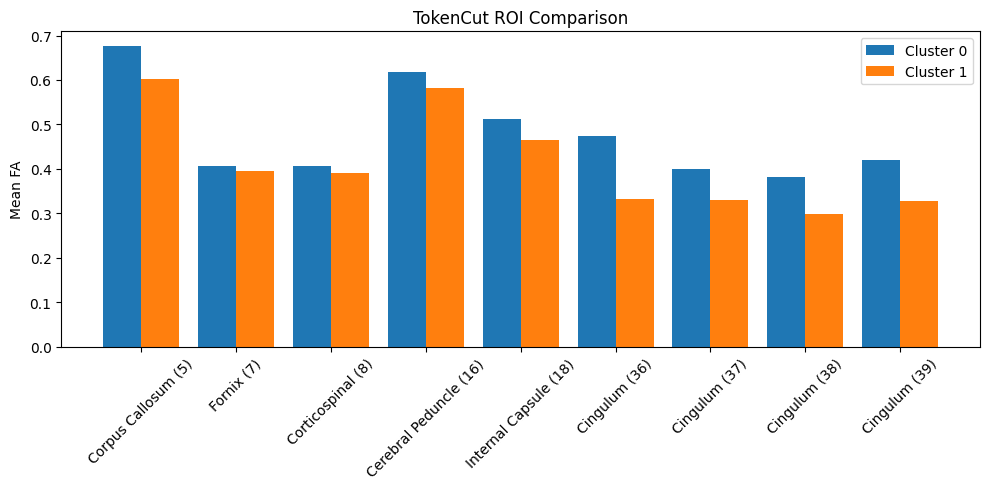

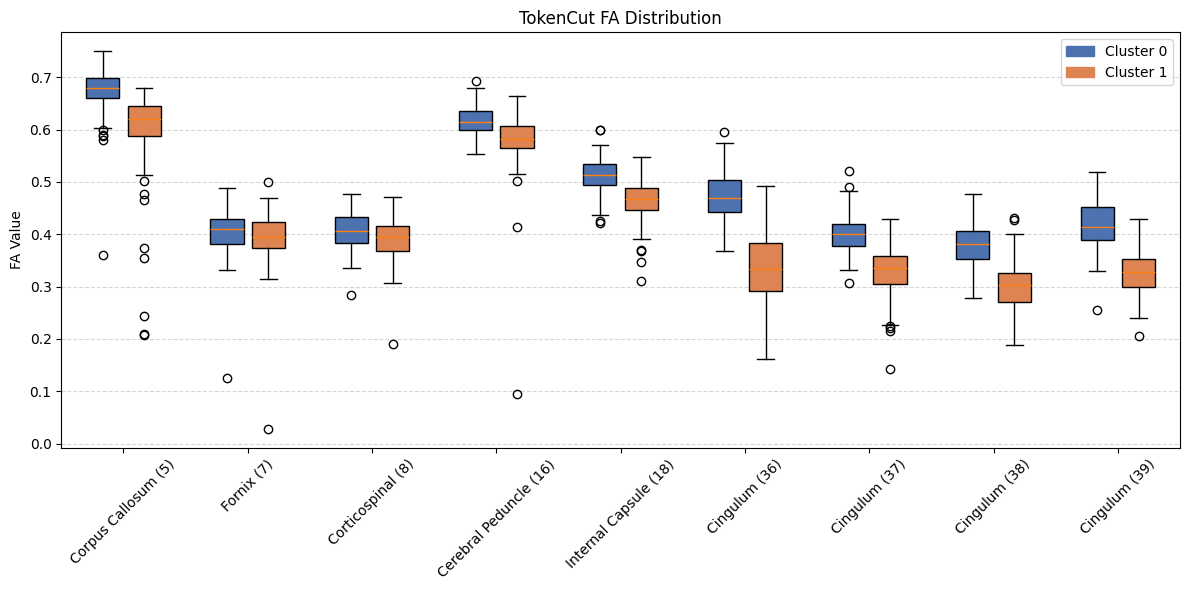

In [12]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
from collections import Counter
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# ================= TOKENCUT MULTI-RUN =================
num_runs = 10
results = []

for run in range(num_runs):
    print(f"\n--- Run {run+1}/{num_runs} ---")

    np.random.seed(run)
    perm = np.random.permutation(X.shape[0])
    X_run = X[perm]
    y_run = y[perm]

    labels, scores = tokencut_on_features(X_run)

    y_pred = labels
    acc = accuracy_score(y_run, y_pred)

    # flip labels if needed
    inv_acc = accuracy_score(y_run, 1 - y_pred)
    if inv_acc > acc:
        y_pred = 1 - y_pred
        acc = inv_acc

    prec = precision_score(y_run, y_pred)
    rec = recall_score(y_run, y_pred)
    f1 = f1_score(y_run, y_pred)

    probs = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)
    logloss = log_loss(y_run, probs)

    results.append({
        "run": run,
        "acc": acc,
        "f1": f1,
        "y_pred": y_pred,
        "X_run": X_run,
        "y_run": y_run
    })

    print(f"Acc: {acc:.4f} | F1: {f1:.4f}")

# ================= BEST RUN =================
best = max(results, key=lambda x: x["acc"])
print("\nBEST RUN:", best["run"], "Accuracy:", best["acc"])

X_best = best["X_run"]
y_pred = best["y_pred"]
y_true = best["y_run"]

# ================= COMMUNITY ANALYSIS =================
print("\n===== COMMUNITY LEVEL ANALYSIS (TokenCut) =====\n")

for k in range(2):
    print(f"Cluster {k}:", Counter(y_true[y_pred == k]))

# ================= ROI SETUP =================
num_rois = 9
bins_per_roi = 20

roi_names = [
    "Corpus Callosum (5)", "Fornix (7)", "Corticospinal (8)",
    "Cerebral Peduncle (16)", "Internal Capsule (18)",
    "Cingulum (36)", "Cingulum (37)", "Cingulum (38)", "Cingulum (39)"
]

roi_indices = {
    roi_names[i]: (i*bins_per_roi, (i+1)*bins_per_roi)
    for i in range(num_rois)
}

bin_edges = np.linspace(0,1,bins_per_roi+1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ================= ROI ANALYSIS =================
roi_stats = {}

for roi, (start,end) in roi_indices.items():
    vals = []
    for k in range(2):
        roi_hist = X_best[y_pred==k, start:end]
        weighted = (roi_hist * bin_centers).sum(axis=1)
        vals.append(weighted.mean())
    roi_stats[roi] = vals

print("\nROI Differences (TokenCut):\n")
for roi in roi_names:
    diff = abs(roi_stats[roi][0] - roi_stats[roi][1])
    print(f"{roi}: {diff:.4f}")

# ================= BAR PLOT =================
roi_means_c0 = [roi_stats[r][0] for r in roi_names]
roi_means_c1 = [roi_stats[r][1] for r in roi_names]

x = np.arange(len(roi_names))

plt.figure(figsize=(10,5))
plt.bar(x-0.2, roi_means_c0, width=0.4, label="Cluster 0")
plt.bar(x+0.2, roi_means_c1, width=0.4, label="Cluster 1")

plt.xticks(x, roi_names, rotation=45)
plt.ylabel("Mean FA")
plt.title("TokenCut ROI Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# ================= BOX PLOT =================
color_c0 = "#4C72B0"
color_c1 = "#DD8452"

plt.figure(figsize=(12,6))

positions = []
data = []
colors = []

gap = 1.5
width = 0.5

for i, (roi, (start,end)) in enumerate(roi_indices.items()):
    c0 = (X_best[y_pred==0, start:end]*bin_centers).sum(axis=1)
    c1 = (X_best[y_pred==1, start:end]*bin_centers).sum(axis=1)

    pos0 = i*gap
    pos1 = i*gap + width

    positions += [pos0, pos1]
    data += [c0, c1]
    colors += [color_c0, color_c1]

box = plt.boxplot(data, positions=positions, widths=0.4, patch_artist=True)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

xticks = [i*gap + width/2 for i in range(len(roi_names))]
plt.xticks(xticks, roi_names, rotation=45)

plt.ylabel("FA Value")
plt.title("TokenCut FA Distribution")

plt.legend(
    handles=[
        plt.Rectangle((0,0),1,1,color=color_c0),
        plt.Rectangle((0,0),1,1,color=color_c1)
    ],
    labels=["Cluster 0","Cluster 1"]
)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


--- Run 1/10 ---
Acc: 0.7133 | F1: 0.7261 | NMI: 0.1402

--- Run 2/10 ---
Acc: 0.7133 | F1: 0.7261 | NMI: 0.1402

--- Run 3/10 ---
Acc: 0.7133 | F1: 0.7261 | NMI: 0.1402

--- Run 4/10 ---
Acc: 0.7133 | F1: 0.7261 | NMI: 0.1402

--- Run 5/10 ---
Acc: 0.7133 | F1: 0.7261 | NMI: 0.1402

--- Run 6/10 ---
Acc: 0.7133 | F1: 0.7261 | NMI: 0.1402

--- Run 7/10 ---
Acc: 0.7133 | F1: 0.7261 | NMI: 0.1402

--- Run 8/10 ---
Acc: 0.7133 | F1: 0.7261 | NMI: 0.1402

--- Run 9/10 ---
Acc: 0.7133 | F1: 0.7261 | NMI: 0.1402

--- Run 10/10 ---
Acc: 0.7133 | F1: 0.7261 | NMI: 0.1402

--- RESULTS (mean ± std over runs) ---
Accuracy:  0.7133 ± 0.0000
Precision: 0.7755 ± 0.0000
Recall:    0.6826 ± 0.0000
F1 Score:  0.7261 ± 0.0000
NMI:       0.1402 ± 0.0000
Log Loss:  0.8301 ± 0.2531

BEST RUN: 0  Acc=0.7133  F1=0.7261  NMI=0.1402

===== COMMUNITY LEVEL ANALYSIS (TokenCut) =====

Cluster 0: Counter({0: 100, 1: 53})
Cluster 1: Counter({1: 114, 0: 33})

Saved: tokencut_roi_stats.csv
                   ROI  Me

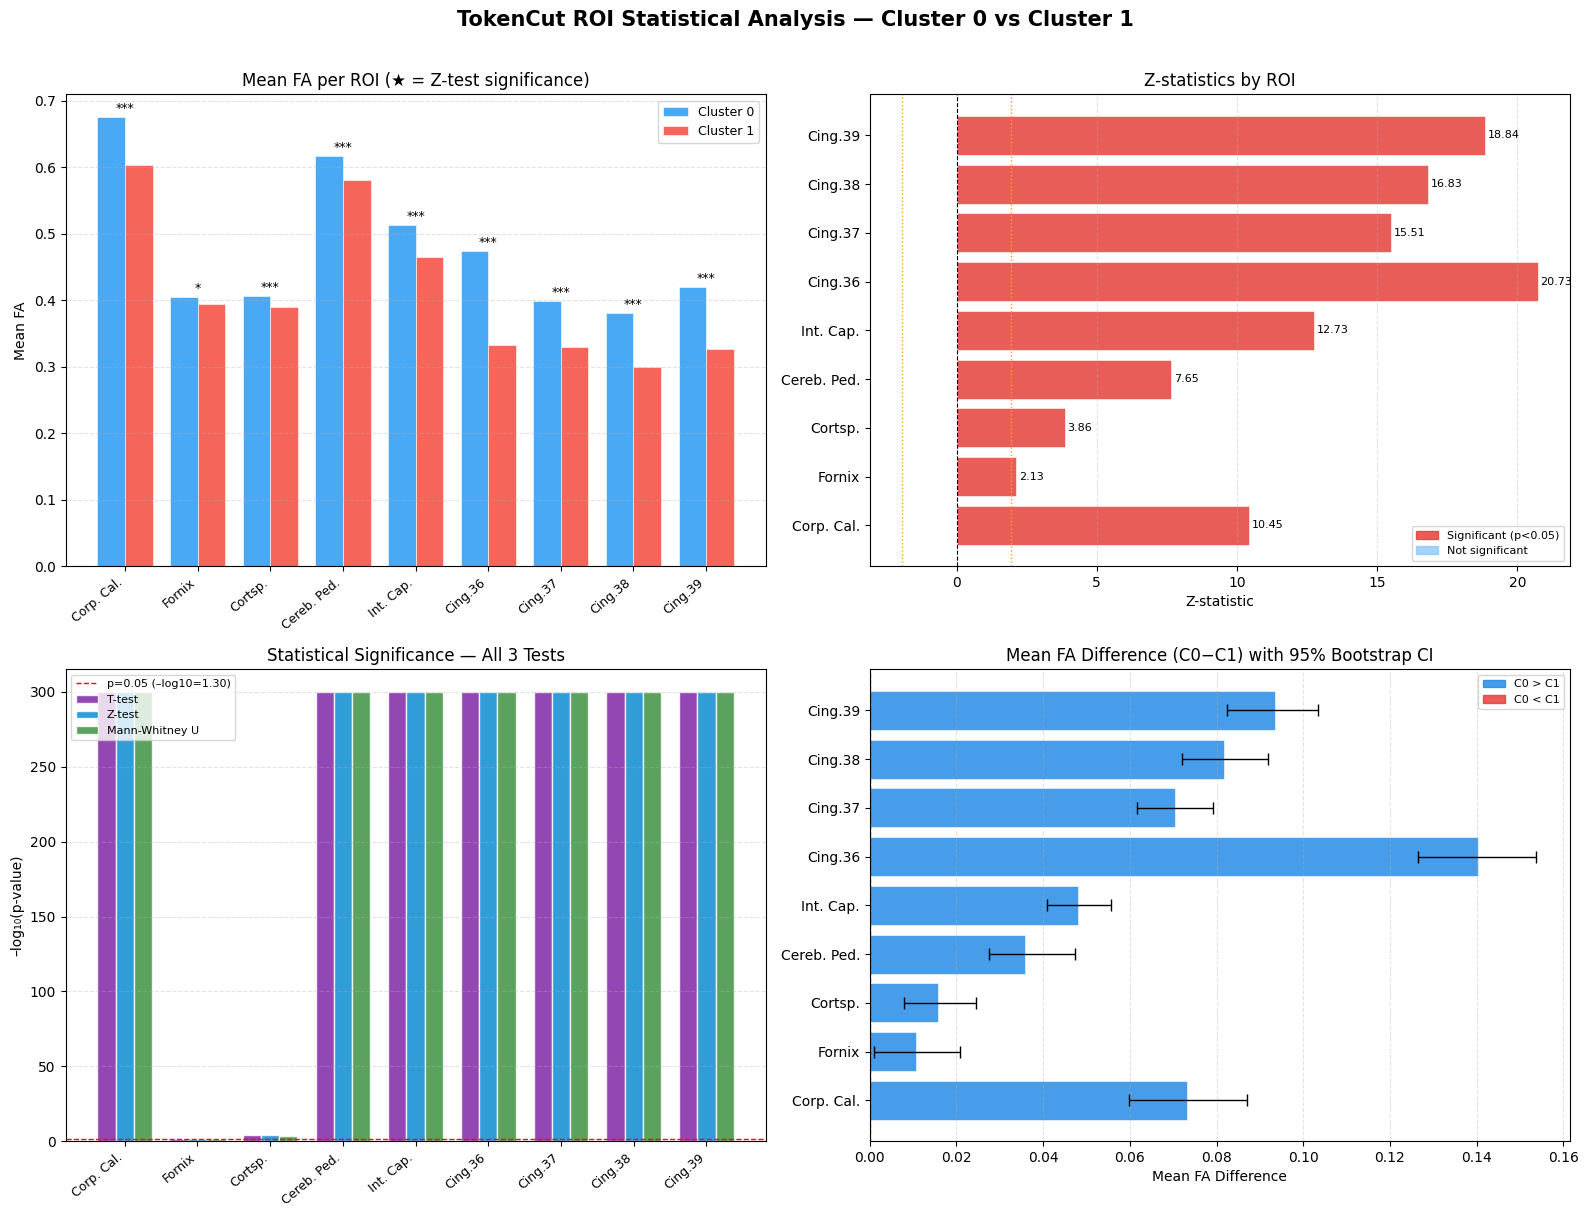

Saved: tokencut_roi_combined_stats.png


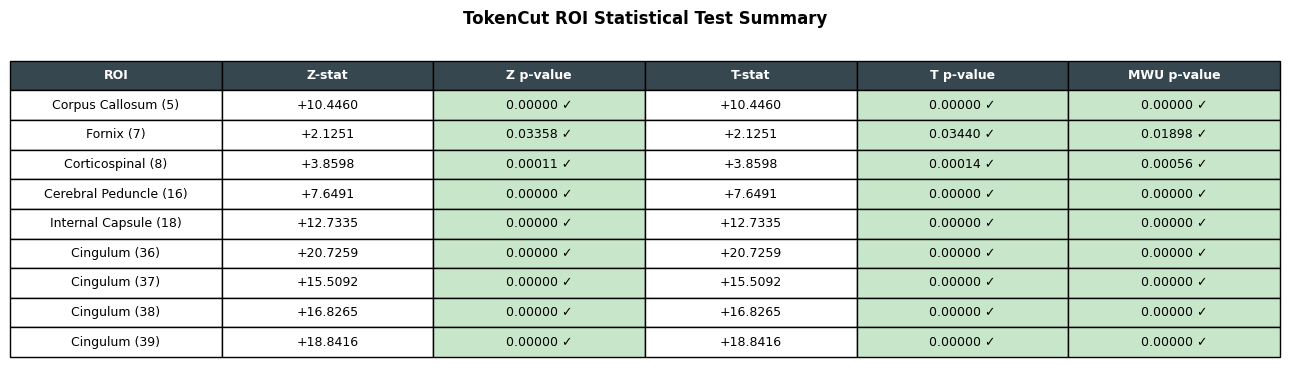

Saved: tokencut_roi_pvalue_table.png


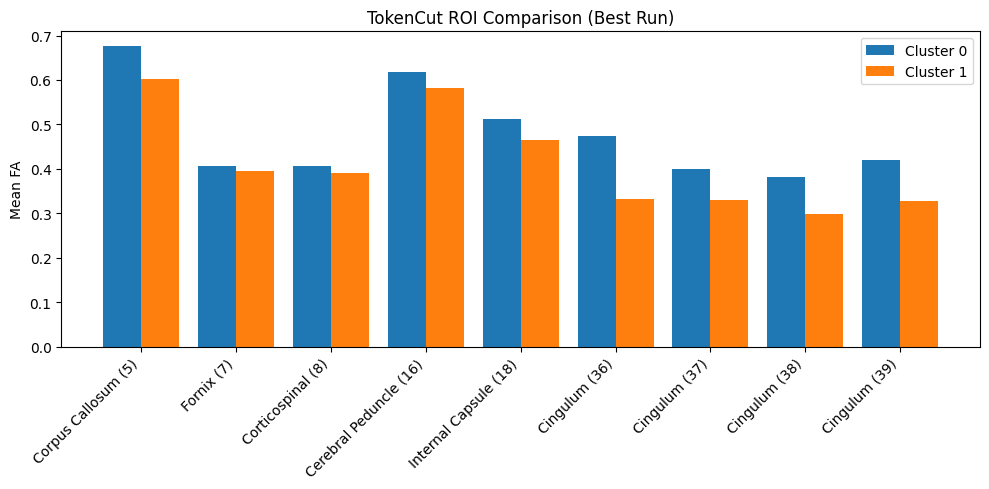

Saved: tokencut_roi_barplot.png


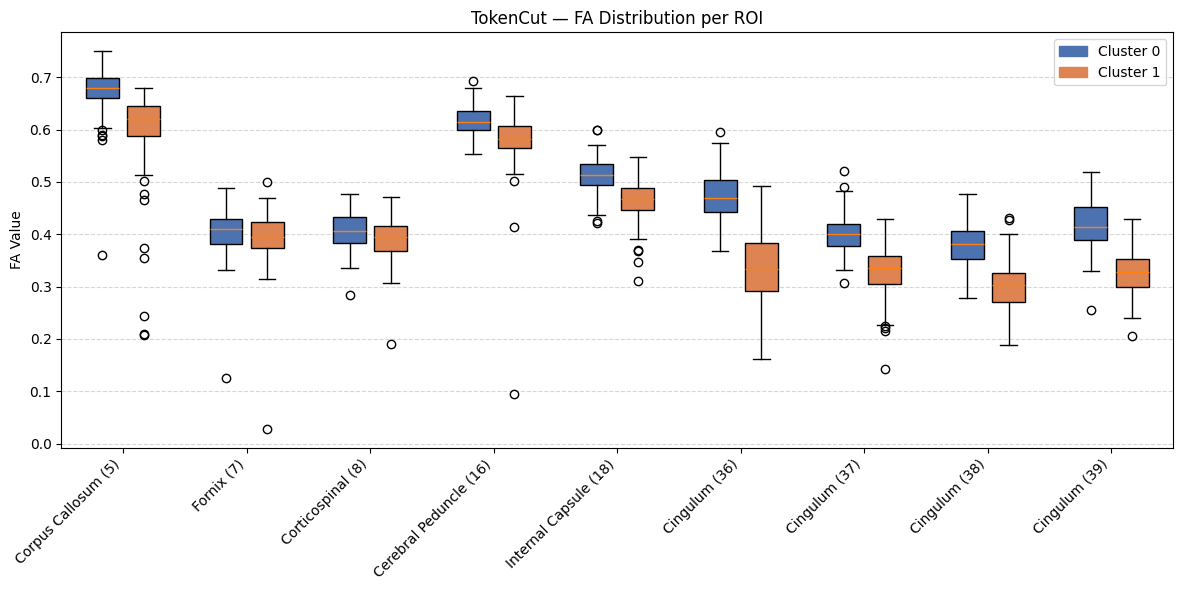

Saved: tokencut_roi_boxplot.png


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, normalized_mutual_info_score
)
from collections import Counter
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.weightstats import ztest

# ════════════════════════════════════════════════════════════════════
#  ROI CONFIG
# ════════════════════════════════════════════════════════════════════
num_rois     = 9
bins_per_roi = 20

roi_names = [
    "Corpus Callosum (5)", "Fornix (7)", "Corticospinal (8)",
    "Cerebral Peduncle (16)", "Internal Capsule (18)",
    "Cingulum (36)", "Cingulum (37)", "Cingulum (38)", "Cingulum (39)"
]
short_names = [
    "Corp. Cal.", "Fornix", "Cortsp.",
    "Cereb. Ped.", "Int. Cap.",
    "Cing.36", "Cing.37", "Cing.38", "Cing.39"
]

roi_indices = {
    roi_names[i]: (i * bins_per_roi, (i + 1) * bins_per_roi)
    for i in range(num_rois)
}

bin_edges   = np.linspace(0, 1, bins_per_roi + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ════════════════════════════════════════════════════════════════════
#  TOKENCUT MULTI-RUN
# ════════════════════════════════════════════════════════════════════
num_runs = 10
results  = []

for run in range(num_runs):
    print(f"\n--- Run {run+1}/{num_runs} ---")

    np.random.seed(run)
    perm  = np.random.permutation(X.shape[0])
    X_run = X[perm]
    y_run = y[perm]

    labels, scores = tokencut_on_features(X_run)

    y_pred  = labels
    acc     = accuracy_score(y_run, y_pred)
    inv_acc = accuracy_score(y_run, 1 - y_pred)
    if inv_acc > acc:
        y_pred = 1 - y_pred
        acc    = inv_acc

    prec    = precision_score(y_run, y_pred, zero_division=0)
    rec     = recall_score(y_run, y_pred,    zero_division=0)
    f1      = f1_score(y_run, y_pred,        zero_division=0)
    probs   = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)
    logloss = log_loss(y_run, probs)
    nmi     = normalized_mutual_info_score(y_run, y_pred, average_method='arithmetic')

    results.append({
        "run": run, "acc": acc, "prec": prec,
        "rec": rec, "f1": f1, "ll": logloss, "nmi": nmi,
        "y_pred": y_pred, "X_run": X_run, "y_run": y_run
    })
    print(f"Acc: {acc:.4f} | F1: {f1:.4f} | NMI: {nmi:.4f}")

# ════════════════════════════════════════════════════════════════════
#  SUMMARY
# ════════════════════════════════════════════════════════════════════
accs  = [r["acc"]  for r in results]
precs = [r["prec"] for r in results]
recs  = [r["rec"]  for r in results]
f1s   = [r["f1"]   for r in results]
lls   = [r["ll"]   for r in results]
nmis  = [r["nmi"]  for r in results]

print("\n--- RESULTS (mean ± std over runs) ---")
print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"NMI:       {np.mean(nmis):.4f} ± {np.std(nmis):.4f}")
print(f"Log Loss:  {np.mean(lls):.4f} ± {np.std(lls):.4f}")

# ════════════════════════════════════════════════════════════════════
#  BEST RUN
# ════════════════════════════════════════════════════════════════════
best   = max(results, key=lambda x: x["acc"])
X_best = best["X_run"]
y_pred = best["y_pred"]
y_true = best["y_run"]

print(f"\nBEST RUN: {best['run']}  "
      f"Acc={best['acc']:.4f}  F1={best['f1']:.4f}  NMI={best['nmi']:.4f}")

# ════════════════════════════════════════════════════════════════════
#  COMMUNITY ANALYSIS
# ════════════════════════════════════════════════════════════════════
print("\n===== COMMUNITY LEVEL ANALYSIS (TokenCut) =====\n")
for k in range(2):
    print(f"Cluster {k}:", Counter(y_true[y_pred == k]))

# ════════════════════════════════════════════════════════════════════
#  COMPUTE ALL STATS  (T-test, Z-test, Mann-Whitney U)
# ════════════════════════════════════════════════════════════════════
roi_stats = {}
for roi, (start, end) in roi_indices.items():
    vals = []
    for k in range(2):
        roi_hist = X_best[y_pred == k, start:end]
        weighted = (roi_hist * bin_centers).sum(axis=1)
        vals.append(weighted.mean())
    roi_stats[roi] = vals

records = []
for roi, (start, end) in roi_indices.items():
    c0_vals = (X_best[y_pred == 0, start:end] * bin_centers).sum(axis=1)
    c1_vals = (X_best[y_pred == 1, start:end] * bin_centers).sum(axis=1)

    mean_c0 = c0_vals.mean()
    mean_c1 = c1_vals.mean()
    diff    = mean_c0 - mean_c1

    t_stat, t_pval = ttest_ind(c0_vals, c1_vals)
    z_stat, z_pval = ztest(c0_vals, c1_vals, value=0)
    u_stat, u_pval = mannwhitneyu(c0_vals, c1_vals, alternative='two-sided')

    records.append({
        "ROI":     roi,
        "Mean_C0": round(mean_c0, 4),
        "Mean_C1": round(mean_c1, 4),
        "Diff":    round(diff, 4),
        "T_stat":  round(t_stat, 4),
        "T_pval":  round(t_pval, 6),
        "T_sig":   t_pval < 0.05,
        "Z_stat":  round(z_stat, 4),
        "Z_pval":  round(z_pval, 6),
        "Z_sig":   z_pval < 0.05,
        "U_stat":  round(u_stat, 4),
        "U_pval":  round(u_pval, 6),
        "U_sig":   u_pval < 0.05,
    })

df = pd.DataFrame(records)

# ── Save CSV ──────────────────────────────────────────────────────
df.to_csv("/home/snu/Downloads/tokencut_roi_stats.csv", index=False)
print("\nSaved: tokencut_roi_stats.csv")
print(df.to_string(index=False))

# ── Print tables ──────────────────────────────────────────────────
print("\nStatistical Significance (T-test):\n")
print(f"{'ROI':<30} | {'T-stat':>10} | {'P-value':>10} | {'Significant':>12}")
print("-" * 70)
for _, row in df.iterrows():
    sig = "Yes ✓" if row["T_sig"] else "No"
    print(f"{row['ROI']:<30} | {row['T_stat']:>10.4f} | {row['T_pval']:>10.5f} | {sig:>12}")

print("\nStatistical Significance (2-Sample Z-test):\n")
print(f"{'ROI':<30} | {'Z-stat':>10} | {'P-value':>10} | {'Significant':>12}")
print("-" * 70)
for _, row in df.iterrows():
    sig = "Yes ✓" if row["Z_sig"] else "No"
    print(f"{row['ROI']:<30} | {row['Z_stat']:>10.4f} | {row['Z_pval']:>10.5f} | {sig:>12}")

# ════════════════════════════════════════════════════════════════════
#  COMBINED 4-PANEL FIGURE
# ════════════════════════════════════════════════════════════════════
x     = np.arange(len(roi_names))
width = 0.38
alpha = 0.82

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "TokenCut ROI Statistical Analysis — Cluster 0 vs Cluster 1",
    fontsize=15, fontweight='bold', y=1.01
)

# ── Panel 1 : Mean FA bar chart ───────────────────────────────────
ax = axes[0, 0]
ax.bar(x - width/2, df["Mean_C0"], width, label="Cluster 0",
       color="#2196F3", alpha=alpha, edgecolor='white', linewidth=0.5)
ax.bar(x + width/2, df["Mean_C1"], width, label="Cluster 1",
       color="#F44336", alpha=alpha, edgecolor='white', linewidth=0.5)

for i, row in df.iterrows():
    stars = ("***" if row["Z_pval"] < 0.001 else
             "**"  if row["Z_pval"] < 0.01  else
             "*"   if row["Z_pval"] < 0.05  else "ns")
    ymax  = max(row["Mean_C0"], row["Mean_C1"]) + 0.003
    ax.text(i, ymax, stars, ha='center', va='bottom', fontsize=9,
            color='black' if stars != "ns" else 'gray')

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
ax.set_ylabel("Mean FA")
ax.set_title("Mean FA per ROI (★ = Z-test significance)")
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.35)

# ── Panel 2 : Z-statistics ────────────────────────────────────────
ax       = axes[0, 1]
colors_z = ["#E53935" if s else "#90CAF9" for s in df["Z_sig"]]
bars     = ax.barh(short_names, df["Z_stat"], color=colors_z,
                   edgecolor='white', linewidth=0.5, alpha=alpha)
ax.axvline(0,     color='black',  linewidth=0.8, linestyle='--')
ax.axvline(-1.96, color='orange', linewidth=1,   linestyle=':', label='±1.96 threshold')
ax.axvline( 1.96, color='orange', linewidth=1,   linestyle=':')

for bar, val in zip(bars, df["Z_stat"]):
    ax.text(val - 0.3 if val < 0 else val + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va='center',
            ha='right' if val < 0 else 'left', fontsize=8)

sig_patch   = mpatches.Patch(color='#E53935', alpha=alpha, label='Significant (p<0.05)')
unsig_patch = mpatches.Patch(color='#90CAF9', alpha=alpha, label='Not significant')
ax.legend(handles=[sig_patch, unsig_patch], fontsize=8, loc='lower right')
ax.set_title("Z-statistics by ROI")
ax.set_xlabel("Z-statistic")
ax.grid(axis='x', linestyle='--', alpha=0.35)

# ── Panel 3 : –log10(p-value) all 3 tests ────────────────────────
ax    = axes[1, 0]
log_t = -np.log10(df["T_pval"].clip(lower=1e-300))
log_z = -np.log10(df["Z_pval"].clip(lower=1e-300))
log_u = -np.log10(df["U_pval"].clip(lower=1e-300))
w3    = 0.25

ax.bar(x - w3, log_t, w3, label="T-test",        color="#7B1FA2", alpha=alpha, edgecolor='white')
ax.bar(x,      log_z, w3, label="Z-test",         color="#0288D1", alpha=alpha, edgecolor='white')
ax.bar(x + w3, log_u, w3, label="Mann-Whitney U", color="#388E3C", alpha=alpha, edgecolor='white')

threshold_line = -np.log10(0.05)
ax.axhline(threshold_line, color='red', linestyle='--', linewidth=1,
           label=f'p=0.05 (–log10={threshold_line:.2f})')

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
ax.set_ylabel("–log₁₀(p-value)")
ax.set_title("Statistical Significance — All 3 Tests")
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.35)

# ── Panel 4 : Signed mean diff + bootstrap CI ─────────────────────
ax = axes[1, 1]
np.random.seed(42)
ci_low, ci_high = [], []
for roi, (start, end) in roi_indices.items():
    c0v = (X_best[y_pred == 0, start:end] * bin_centers).sum(axis=1)
    c1v = (X_best[y_pred == 1, start:end] * bin_centers).sum(axis=1)
    boot_diffs = [
        np.random.choice(c0v, len(c0v), replace=True).mean() -
        np.random.choice(c1v, len(c1v), replace=True).mean()
        for _ in range(1000)
    ]
    ci_low.append(np.percentile(boot_diffs, 2.5))
    ci_high.append(np.percentile(boot_diffs, 97.5))

diffs    = df["Diff"].values
err_low  = diffs - np.array(ci_low)
err_high = np.array(ci_high) - diffs
colors_d = ["#E53935" if d < 0 else "#1E88E5" for d in diffs]

ax.barh(short_names, diffs,
        xerr=[err_low, err_high],
        color=colors_d, alpha=alpha,
        edgecolor='white', linewidth=0.5,
        error_kw=dict(ecolor='black', capsize=4, linewidth=1))
ax.axvline(0, color='black', linewidth=0.9, linestyle='--')
ax.set_title("Mean FA Difference (C0−C1) with 95% Bootstrap CI")
ax.set_xlabel("Mean FA Difference")
ax.grid(axis='x', linestyle='--', alpha=0.35)

pos_patch = mpatches.Patch(color='#1E88E5', alpha=alpha, label='C0 > C1')
neg_patch = mpatches.Patch(color='#E53935', alpha=alpha, label='C0 < C1')
ax.legend(handles=[pos_patch, neg_patch], fontsize=8)

plt.tight_layout()
plt.savefig("/home/snu/Downloads/tokencut_roi_combined_stats.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tokencut_roi_combined_stats.png")

# ════════════════════════════════════════════════════════════════════
#  P-VALUE SUMMARY TABLE AS IMAGE
# ════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(13, 4))
ax2.axis('off')

table_data = []
for _, row in df.iterrows():
    def fmt(pval, sig):
        return f"{pval:.5f} {'✓' if sig else '✗'}"
    table_data.append([
        row["ROI"],
        f"{row['Z_stat']:+.4f}",
        fmt(row["Z_pval"], row["Z_sig"]),
        f"{row['T_stat']:+.4f}",
        fmt(row["T_pval"], row["T_sig"]),
        fmt(row["U_pval"], row["U_sig"]),
    ])

col_labels = ["ROI", "Z-stat", "Z p-value", "T-stat", "T p-value", "MWU p-value"]
tbl = ax2.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

for (row_idx, col_idx), cell in tbl.get_celld().items():
    if row_idx == 0:
        cell.set_facecolor('#37474F')
        cell.set_text_props(color='white', fontweight='bold')
    elif col_idx in [2, 4, 5]:
        txt = cell.get_text().get_text()
        cell.set_facecolor('#C8E6C9' if '✓' in txt else '#FFCDD2')

ax2.set_title("TokenCut ROI Statistical Test Summary",
              fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig("/home/snu/Downloads/tokencut_roi_pvalue_table.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tokencut_roi_pvalue_table.png")

# ════════════════════════════════════════════════════════════════════
#  ORIGINAL BAR PLOT
# ════════════════════════════════════════════════════════════════════
roi_means_c0 = [roi_stats[r][0] for r in roi_names]
roi_means_c1 = [roi_stats[r][1] for r in roi_names]
x_pos        = np.arange(len(roi_names))

plt.figure(figsize=(10, 5))
plt.bar(x_pos - 0.2, roi_means_c0, width=0.4, label="Cluster 0")
plt.bar(x_pos + 0.2, roi_means_c1, width=0.4, label="Cluster 1")
plt.xticks(x_pos, roi_names, rotation=45, ha='right')
plt.ylabel("Mean FA")
plt.title("TokenCut ROI Comparison (Best Run)")
plt.legend()
plt.tight_layout()
plt.savefig("/home/snu/Downloads/tokencut_roi_barplot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tokencut_roi_barplot.png")

# ════════════════════════════════════════════════════════════════════
#  ORIGINAL BOX PLOT
# ════════════════════════════════════════════════════════════════════
color_c0 = "#4C72B0"
color_c1 = "#DD8452"

plt.figure(figsize=(12, 6))
positions, data, colors = [], [], []
gap, bw = 1.5, 0.5

for i, (roi, (start, end)) in enumerate(roi_indices.items()):
    c0 = (X_best[y_pred == 0, start:end] * bin_centers).sum(axis=1)
    c1 = (X_best[y_pred == 1, start:end] * bin_centers).sum(axis=1)
    positions += [i * gap, i * gap + bw]
    data      += [c0, c1]
    colors    += [color_c0, color_c1]

box = plt.boxplot(data, positions=positions, widths=0.4, patch_artist=True)
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

xticks = [i * gap + bw / 2 for i in range(len(roi_names))]
plt.xticks(xticks, roi_names, rotation=45, ha='right')
plt.ylabel("FA Value")
plt.title("TokenCut — FA Distribution per ROI")
plt.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=color_c0),
        plt.Rectangle((0, 0), 1, 1, color=color_c1)
    ],
    labels=["Cluster 0", "Cluster 1"]
)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("/home/snu/Downloads/tokencut_roi_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tokencut_roi_boxplot.png")

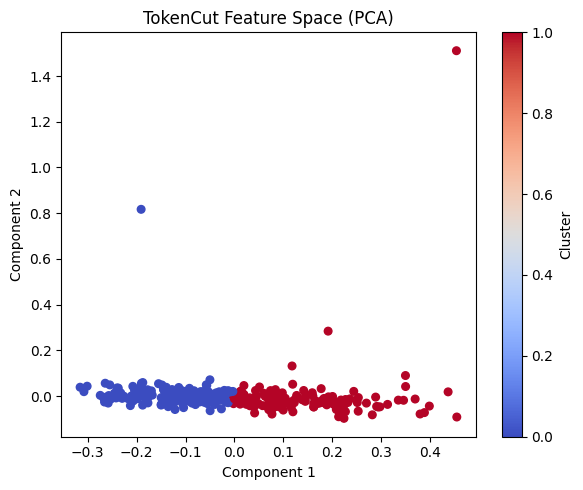

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X = np.load("/home/snu/Downloads/X.npy")
y_pred = np.load("/home/snu/Downloads/tokencut_labels.npy")

pca = PCA(n_components=2)
Z = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(Z[:,0], Z[:,1], c=y_pred, cmap='coolwarm', s=30)

plt.title("TokenCut Feature Space (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")

plt.tight_layout()
plt.show()